In [1]:
import numpy as np
from pathlib import Path
path_folder = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc3/155Vs/10Hz/2026_02_03__RIGINM__DA__155Vs_10Hz__ALC3_INM001_03bW02R01M"
# grab one weights file and one voltammogram file
w = next(Path(path_folder).rglob("weights_3d.npy"))
v = next(Path(path_folder).rglob("voltammograms.npy"))
for f in (w, v):
    a = np.load(f, mmap_mode='r')
    print(f"{f.name:25s} shape={a.shape}  dtype={a.dtype}")

weights_3d.npy            shape=(35, 150, 1000, 10)  dtype=float32
voltammograms.npy         shape=(35, 1000, 150)  dtype=float32


In [1]:
from pathlib import Path
p = Path("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF")
for pat in ["weights_3d.npy","weights_6d.npy","combined_3d.npy","combined_6d.npy"]:
    print(f"{pat:20s} {len(list(p.rglob(pat)))}")
print(sorted({f.name for f in p.rglob('*.npy')}))

weights_3d.npy       28
weights_6d.npy       0
combined_3d.npy      28
combined_6d.npy      4
['combined.npy', 'combined6d.npy', 'combined_3d.npy', 'combined_6d.npy', 'combined_fine_tune_0.npy', 'forecast_3d.npy', 'forecast_fine_tune_0.npy', 'labels.npy', 'voltammograms.npy', 'weights.npy', 'weights_3d.npy', 'weights_collapsed.npy', 'weights_collapsed_3d.npy', 'weights_fine_tune_0.npy']


In [4]:
import numpy as np
combined_6d = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_10_02__RIGINM__NE__155Vs_10Hz__ALC2_INM001_02bW02R01M/NE/combined_6d.npy')

In [5]:
print(combined_6d.shape)

(35, 150, 1000, 81)


In [ ]:
import decoding_core.utils as utils
FOLDER = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF"
act_arr,lbl_arr,probe_arr = utils.get_activation_label_pair(FOLDER, collapsed=False)
def inspect(act, lbl, probe):
    print("=== shapes / dtype ===")
    print("act", act.shape, act.dtype, f"{act.nbytes/1e9:.1f} GB")
    print("lbl", lbl.shape, lbl.dtype)

    print("\n=== finite check (DynaMix rollouts can diverge) ===")
    print("act NaN/Inf:", np.isnan(act).sum(), np.isinf(act).sum())
    print("lbl NaN/Inf:", np.isnan(lbl).sum(), np.isinf(lbl).sum())

    print("\n=== label columns — identify pH by magnitude ===")
    for j in range(lbl.shape[1]):
        col = lbl[:, j]
        print(f"  col {j}: min {col.min():8.3f}  max {col.max():9.3f}  "
              f"mean {col.mean():8.3f}  std {col.std():7.3f}")

    print("\n=== near-zero-variance features (z-score blow-up risk) ===")
    s = act.reshape(act.shape[0], -1).std(axis=0)
    print(f"  features with std<1e-6: {(s < 1e-6).sum()} / {s.size}")
    print(f"  min nonzero std: {s[s > 0].min():.2e}")

    print("\n=== activation simplex check (did the right array load?) ===")
    if act.shape[-1] > 1:                       # activation arm only
        sw = act.reshape(-1, act.shape[-1]).sum(axis=1)
        print(f"  per-timestep expert sum: mean {sw.mean():.3f}  "
              f"min {sw.min():.3f}  max {sw.max():.3f}  (expect ~1.0)")

    print("\n=== probes / fold sizing ===")
    u = np.unique(probe)
    print(f"  {len(u)} unique probes, {len(probe)} total rows")
    print(f"  est. activation RAM if float32: {len(probe)*10000*4/1e9:.1f} GB raw, "
          f"~2-3x that at peak")

inspect(act_arr, lbl_arr, probe_arr)

Found 28 paths
Getting pairs not collapsed.
First activation shape(5250, 1000, 10)
First label shape(5250, 4)
=== shapes / dtype ===
act (127050, 1000, 10) float32 5.1 GB
lbl (127050, 4) float32

=== finite check (DynaMix rollouts can diverge) ===
act NaN/Inf: 0 0
lbl NaN/Inf: 0 0

=== label columns — identify pH by magnitude ===
  col 0: min    0.000  max  2520.000  mean  462.645  std 721.411
  col 1: min    0.000  max  2520.000  mean  465.620  std 724.686
  col 2: min    0.000  max  2490.000  mean  461.653  std 720.148
  col 3: min    7.000  max     7.800  mean    7.400  std   0.070

=== near-zero-variance features (z-score blow-up risk) ===
  features with std<1e-6: 0 / 10000
  min nonzero std: 3.00e-06

=== activation simplex check (did the right array load?) ===
  per-timestep expert sum: mean 1.000  min 1.000  max 1.000  (expect ~1.0)

=== probes / fold sizing ===
  7 unique probes, 127050 total rows
  est. activation RAM if float32: 5.1 GB raw, ~2-3x that at peak


In [ ]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import umap

In [ ]:
import decoding_core.utils as utils

In [ ]:
train, val, test, _, _, _,_,_ = utils.load_activation_data("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF",
                                                            test_probe="ALC2_INM001_02bW02R01M",
                                                            ret_np=True,
                                                            classification=False, combined=True, model_last='fine_tune_0') 

In [1]:
import numpy as np
from tslearn.metrics import gak, sigma_gak
'''arr1 = np.zeros(shape=(10 , 20, 10000,10))
arrs = np.split(arr1, arr1.shape[-1] ,axis=3)
arr2 = np.zeros(shape=(10, 20, 10000, 1))


arrs.append(arr2)
print(len(arrs))
print(type(arrs[0]))
print(arrs[10].shape)
np.concatenate(arrs, axis=3).shape'''

'arr1 = np.zeros(shape=(10 , 20, 10000,10))\narrs = np.split(arr1, arr1.shape[-1] ,axis=3)\narr2 = np.zeros(shape=(10, 20, 10000, 1))\n\n\narrs.append(arr2)\nprint(len(arrs))\nprint(type(arrs[0]))\nprint(arrs[10].shape)\nnp.concatenate(arrs, axis=3).shape'

In [11]:
test = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/artificial_dysys/fine_tune_1/test.npy")
context = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/artificial_dysys/fine_tune_1/context.npy")
data = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/artificial_dysys/fine_tune_1/data.npy")

clipped = np.concatenate([data,np.zeros_like(data), np.zeros_like(data)], axis=-1)

In [12]:

data = np.transpose(data,(1,0,2))
print(data.shape)

(14850, 1000, 3)


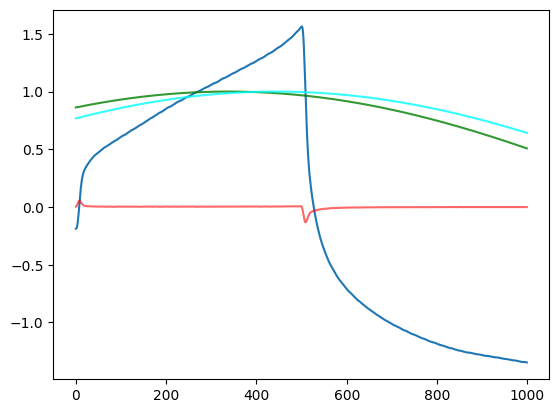

In [27]:
import matplotlib.pyplot as plt
a = 5000
plt.plot(np.arange(1000), data[a,:,0])
plt.plot(np.arange(1000), data[a,:,1], color ='green', alpha=0.8)
plt.plot(np.arange(1000), data[a,:,2], color ='cyan', alpha=0.8)
plt.plot(np.arange(1000), np.gradient(data[0,:,0],np.arange(1000) ), color ='r', alpha=0.6)

In [6]:
sigma = sigma_gak(data)

print(sigma)
print(test.shape)
print(data.shape)
print(context.shape)
print(clipped.shape)

122.74297788457915
(10000, 3300, 3)
(1000, 14850, 3)
(9000, 14850, 3)
(1000, 14850, 9)


In [26]:
k = gak(data[0], data[1],sigma)

/home/team/.pyenv/versions/dynamix/lib/python3.11/site-packages/tslearn/metrics/_gak.py:175: RuntimeWarning: invalid value encountered in scalar divide
  return _unnormalized_gak(s1, s2, sigma=sigma, backend=be) / denom


In [27]:
print(k)

nan


In [3]:
arr3 = np.repeat(arr1, 9, axis=2)
print(arr3.shape)

(10, 20, 90000, 10)


In [7]:
arr3 = arr3.reshape(-1, 90000, 10)
(arr3.shape)

(200, 90000, 10)

In [1]:
from src_v1.utils import combine_act, spit_compliant_data

In [3]:
path_folder = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/"
out_folder = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/artificial_dysys/fine_tune_1/"
probes = ['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M',
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M',
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M',
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M',
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M',
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M',
 'ALCIS_155_macroREF__ALC4_INM001_04bW08R03M']


In [ ]:

X_data_delay, X_context_delay, X_test_delay, _ = spit_compliant_data(path_folder=path_folder, out_path=out_folder, probe_id_substr="ALCIS_155_macroREF__ALC2_INM001_02bW02R01M", embedding='delay_embedding')

In [5]:
print(X_data_delay.shape)
print(X_context_delay.shape)
print(X_test_delay.shape)

(602, 14850, 3)
(8602, 14850, 3)
(9602, 3300, 3)


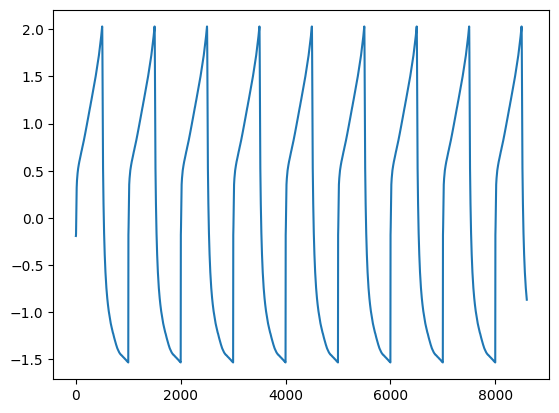

In [16]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(np.arange(8602),X_context_delay[:,0,2])

In [4]:

out_folder = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/artificial_dysys/fine_tune_2/"


X_data_pos, X_context_pos, X_test_pos, _ = spit_compliant_data(path_folder=path_folder, out_path=out_folder, probe_id_substr="ALCIS_155_macroREF__ALC2_INM001_02bW02R01M", phi_mode="linspace", tau=1000)

Found 28 paths
Getting pairs not collapsed.
Getting raw voltammograms
ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 18150 sweeps
113 unique mixtures, ~161 sweeps each
combos -> train 91  test 22
rows   -> train 14850  test 3300
tau = 1000   phis = [0.     1.5708]
Context shape: (9000, 14850, 3)
Data shape:    (1000, 14850, 3)
Test shape:    (10000, 3300, 3)
  data: absmax 2.425  per-channel std [1.005 0.708 0.707]
  context: absmax 2.425  per-channel std [0.633 0.354 0.354]
  test: absmax 1.901  per-channel std [0.978 0.707 0.706]


In [5]:
print("context ch0:", X_context_pos[:,:,0].std(), " data ch0:", X_data_pos[:,:,0].std())
print("context sines:", X_context_pos[:1000,:,1].std())   # first sweep only
print("ratio:", X_context_pos[:,:,1].std() / X_data_pos[:,:,1].std())

context ch0: 0.9999999  data ch0: 1.0000001
context sines: 0.70710677
ratio: 1.0


In [7]:
import numpy as np

C = np.load(out_folder + "context.npy")
print(C.shape, C.dtype)
print("axis=(0,1)     :", C.std(axis=(0,1)))
print("per-channel    :", [float(C[:,:,k].std()) for k in range(3)])
print("f64            :", C.std(axis=(0,1), dtype=np.float64))

(9000, 14850, 3) float32
axis=(0,1)     : [0.6329519  0.35430354 0.35430354]
per-channel    : [0.9999998807907104, 0.7071067690849304, 0.70710688829422]
f64            : [0.99999966 0.70710678 0.70710678]


In [17]:
print(X_data_pos.shape)
print(X_context_pos.shape)
print(X_test_pos.shape)

(1000, 14850, 3)
(9000, 14850, 3)
(10000, 3300, 3)


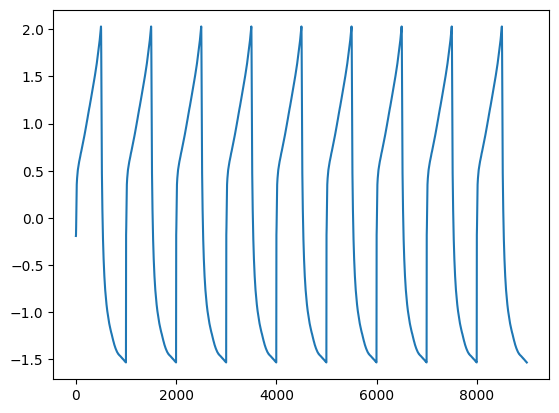

In [23]:

plt.plot(np.arange(9000),X_context_pos[:,0,0])

In [4]:

paths = combine_act(path_folder="/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/P3_FOR/alc_p3/155Vs/10Hz", model_last='fine_tune_2_epoch50')

Found 1 paths
saved /home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/P3_FOR/alc_p3/155Vs/10Hz/2026_07_01__RIGINM__5HT__155Vs_10Hz__ALC_FOR001_03bW01R01M/5HT/combined_fine_tune_2_epoch50.npy  (35, 150, 1000, 11)


In [4]:
final = []
for i, arr in enumerate(act_arr):
    k = arr
    k.append(volta_arr[i])
    final.append(np.concatenate(k, axis=3))

print(len(final))

28


In [5]:
final[0].shape

(35, 150, 1000, 11)

In [8]:
paths[2]

PosixPath('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc1/155Vs/10Hz/2025_09_30__RIGINM__DA__155Vs_10Hz__ALC1_INM001_01bW04R01M/DA')

In [5]:
print(len(act_arr))
print(type(act_arr[0]))
print(len(volta_arr))
print(type(volta_arr))
print(len(act_arr[0]))
print(volta_arr[0].shape)
print(len(paths))

28
<class 'list'>
28
<class 'list'>
10
(35, 150, 1000, 1)
28


In [6]:
act_arr[0].append(volta_arr[0])


In [7]:
k = act_arr[0]
print(len(k))
act_arr_f = np.concatenate(k, axis=3)

11


In [9]:
act_arr_f.shape

(35, 150, 1000, 11)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

OUT = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/param_plots"

# ----------------------------------------------------------------------
# Table 1 : hyperparameters
# ----------------------------------------------------------------------
params = ["Classic", "P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8", "P9"]
start_lr = [1e-3, 1e-3, 1e-4, 1e-4, 1e-4, 1e-5, 1e-4, 1e-4, 1e-4, 1e-4]
min_lr   = [1e-6, 1e-6, 1e-8, 1e-4, 1e-8, 1e-10, 1e-8, 1e-8, 1e-8, 1e-8]
depth    = [6, 8, 8, 6, 12, 6, 10, 8, 10, 8]
kernel   = [40, 60, 60, 40, 80, 80, 60, 80, 80, 100]

# one distinct colour per parameter set, reused across every panel/figure
cmap = plt.get_cmap("tab10")
PCOLOR = {p: cmap(i % 10) for i, p in enumerate(params)}
colors = [PCOLOR[p] for p in params]

x = np.arange(len(params))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# learning rates -> log scale
for ax, vals, name in [(axes[0, 0], start_lr, "start_lr"),
                       (axes[0, 1], min_lr, "min_lr")]:
    ax.bar(x, vals, color=colors, edgecolor="black", linewidth=0.6)
    ax.set_yscale("log")
    ax.set_title(name)
    ax.set_ylabel("learning rate (log)")
    for xi, v in zip(x, vals):
        ax.text(xi, v * 1.6, f"{v:.0e}", ha="center", va="bottom",
                fontsize=7, rotation=90)
    ax.set_ylim(top=max(vals) * 60)

# architecture -> linear scale
for ax, vals, name in [(axes[1, 0], depth, "Depth"),
                       (axes[1, 1], kernel, "Kernel size")]:
    ax.bar(x, vals, color=colors, edgecolor="black", linewidth=0.6)
    ax.set_title(name)
    ax.set_ylabel(name)
    for xi, v in zip(x, vals):
        ax.text(xi, v + max(vals) * 0.02, str(v), ha="center",
                va="bottom", fontsize=8)
    ax.set_ylim(top=max(vals) * 1.18)

for ax in axes.ravel():
    ax.set_xticks(x)
    ax.set_xticklabels(params, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

fig.suptitle("Parameter sets — hyperparameter configuration", fontsize=14)
fig.tight_layout()
fig.savefig(f"{OUT}/parameters_barplot.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# ----------------------------------------------------------------------
# Table 2 : R^2 results
# ----------------------------------------------------------------------
# (label, parameter-set, input-type)  input: 'v' = voltammogram, 'df' = dynamix finetuned
cols = [
    ("v_normal",  "Classic", "v"),
    ("v_p1",      "P1",      "v"),
    ("df_normal", "Classic", "df"),
    ("df_p1",     "P1",      "df"),
    ("df_p2",     "P2",      "df"),
    ("df_p3",     "P3",      "df"),
    ("df_p4",     "P4",      "df"),
    ("df_p5",     "P5",      "df"),
    ("df_p6",     "P6",      "df"),
    ("df_p7",     "P7",      "df"),
    ("v_p7",      "P7",      "v"),
    ("df_p8",     "P8",      "df"),
    ("df_p9",     "P9",      "df"),
]
vals = {
    "5HT": [0.65, 0.65, 0.51, 0.59, 0.71, 0.46, 0.72, 0.38, 0.67, 0.78, 0.74, 0.66, 0.74],
    "DA":  [0.90, 0.92, 0.88, 0.88, 0.88, 0.92, 0.92, 0.89, 0.90, 0.92, 0.91, 0.91, 0.93],
    "NE":  [0.86, 0.88, 0.84, 0.85, 0.81, 0.85, 0.83, 0.77, 0.87, 0.84, 0.86, 0.84, 0.83],
}

analytes = list(vals)
n = len(cols)
width = 0.8 / n
xa = np.arange(len(analytes))

fig, ax = plt.subplots(figsize=(14, 6))

for i, (lab, pset, kind) in enumerate(cols):
    heights = [vals[a][i] for a in analytes]
    off = (i - (n - 1) / 2) * width
    ax.bar(xa + off, heights, width,
           color=PCOLOR[pset],
           alpha=1.0 if kind == "df" else 0.55,
           hatch="" if kind == "df" else "//",
           edgecolor="black", linewidth=0.5, label=lab)
    for xi, h in zip(xa + off, heights):
        ax.text(xi, h + 0.008, f"{h:.2f}", ha="center", va="bottom",
                fontsize=6, rotation=90)

ax.set_xticks(xa)
ax.set_xticklabels(analytes, fontsize=12)
ax.set_ylabel(r"$R^2$")
ax.set_ylim(0, 1.06)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.set_title(r"Decoding performance ($R^2$) per analyte and parameter set")

# legend 1: parameter set colours
used = []
for _, p, _ in cols:
    if p not in used:
        used.append(p)
leg1 = ax.legend(handles=[Patch(facecolor=PCOLOR[p], edgecolor="black", label=p)
                          for p in used],
                 title="Parameter set", ncol=1,
                 loc="upper left", bbox_to_anchor=(1.005, 1.0), frameon=False)
ax.add_artist(leg1)

# legend 2: input type
ax.legend(handles=[
    Patch(facecolor="grey", edgecolor="black", label="dynamix finetuned (df_)"),
    Patch(facecolor="grey", alpha=0.55, hatch="//", edgecolor="black",
          label="voltammogram (v_)")],
    title="Input", loc="upper left", bbox_to_anchor=(1.005, 0.42), frameon=False)

fig.tight_layout()
fig.savefig(f"{OUT}/results_r2_barplot.png", dpi=200, bbox_inches="tight")
plt.close(fig)
print("done")

done


ok


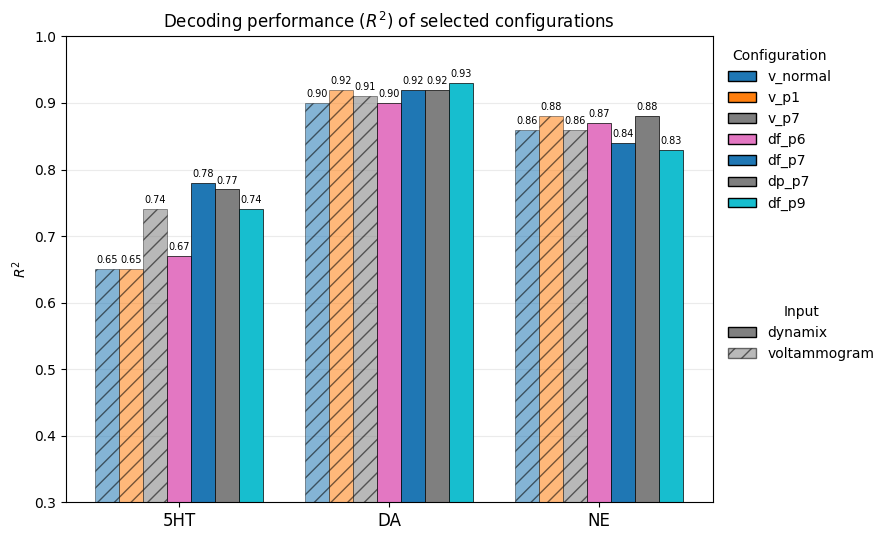

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

OUT = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/param_plots"
params = ["Classic","P1","P2","P3","P4","P5","P6","P7","P8","P9", 'P7_p']
cmap = plt.get_cmap("tab10")
PCOLOR = {p: cmap(i % 10) for i, p in enumerate(params)}

cols = [
    ("v_normal",  "Classic", "v",  0.65, 0.90, 0.86),
    ("v_p1",      "P1",      "v",  0.65, 0.92, 0.88),
    ("v_p7",      "P7",      "v",  0.74, 0.91, 0.86),
    ("df_p6",     "P6",      "df", 0.67, 0.90, 0.87),
    ("df_p7",     "P7_p",      "df", 0.78, 0.92, 0.84),
    ("dp_p7",     "P7",      "dp", 0.77, 0.92, 0.88),
    ("df_p9",     "P9",      "df", 0.74, 0.93, 0.83),
]
analytes = ["5HT", "DA", "NE"]
n = len(cols); width = 0.8 / n
xa = np.arange(len(analytes))

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, (lab, pset, kind, *h) in enumerate(cols):
    off = (i - (n - 1) / 2) * width
    ax.bar(xa + off, h, width, color=PCOLOR[pset],
           alpha=1.0 if kind == "df" or kind == 'dp' else 0.55,
           hatch="" if kind == "df" or kind == 'dp' else "//",
           edgecolor="black", linewidth=0.5)
    for xi, v in zip(xa + off, h):
        ax.text(xi, v + 0.006, f"{v:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(xa); ax.set_xticklabels(analytes, fontsize=12)
ax.set_ylabel(r"$R^2$"); ax.set_ylim(0, 1.06)
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
ax.set_title(r"Decoding performance ($R^2$) — selected configurations")

leg1 = ax.legend(handles=[Patch(facecolor=PCOLOR[p], edgecolor="black",
                               alpha=1.0 if kind == "df" or kind == 'dp' else 0.55,
                               hatch="" if kind == "df" or kind == 'dp' else "//", label=l)
                          for l, p, k, *_ in cols],
                 title="Configuration", loc="upper left",
                 bbox_to_anchor=(1.005, 1.0), frameon=False)
ax.add_artist(leg1)
ax.legend(handles=[Patch(facecolor="grey", edgecolor="black", label="dynamix"),
                   Patch(facecolor="grey", alpha=0.55, hatch="//", edgecolor="black",
                         label="voltammogram")],
          title="Input", loc="upper left", bbox_to_anchor=(1.005, 0.45), frameon=False)
fig.tight_layout()
fig.savefig(f"{OUT}/results_r2_subset.png", dpi=200, bbox_inches="tight")

# zoomed version
ax.set_ylim(0.3, 1.0)
ax.set_title(r"Decoding performance ($R^2$) of selected configurations")
fig.savefig(f"{OUT}/results_r2_subset_zoom.png", dpi=200, bbox_inches="tight")
print("ok")